# Descriptive Statistical Analysis of Audience Reviews: A Case Study of 3 Idiots

This notebook is structured as a formal analytical study of audience review behavior for the film *3 Idiots*. The objective is to present evidence-based descriptive statistical findings, visualize distributional characteristics, and interpret audience response in a manner consistent with academic entertainment analytics research.

## Project Overview

**Objective:** To quantify the review distribution for *3 Idiots* and translate numerical review patterns into meaningful audience insights.

**Research Motivation:** Audience reviews are a primary source of viewer sentiment in entertainment analytics. Systematic descriptive analysis can reveal whether the film draws a polarized reaction, broad consensus, or strong preference bias.

**Importance of Audience Analytics:** In entertainment research, review metrics inform programming, marketing, and distribution strategies. Quantitative review analysis reduces reliance on anecdotal impressions and allows decision-makers to triangulate sentiment, satisfaction, and engagement.

**Role of Review Analysis in Entertainment Research:** Review ratings are an observable signal of reception. Descriptive statistics transform the raw behavioral data from reviewers into interpretable metrics for film reception, approval levels, and audience agreement.

## Research Context

Audience behavior analysis in film studies seeks to identify the underlying patterns that shape collective opinion. Quantitative review analysis offers an evidence-based foundation for understanding reception, reducing the bias introduced by selected testimonials.

Modern entertainment analytics relies on statistical measures to codify sentiment and assess whether a title appeals uniformly or exhibits divergent responses. By translating review ratings into distributional metrics, analysts can distinguish between consensus and fragmentation in audience perception.

## Dataset Overview

| Column | Description | Relevance |
|---|---|---|
| `Username` | Reviewer identifier | Enables sampling consistency and audit of review provenance. |
| `Rating` | Numerical rating | Direct measurement of satisfaction and approval. |
| `Review Title` | Review headline | Provides a concise sentiment signal and helps categorize reviewer framing. |
| `Review Text` | Full review | Captures qualitative opinion, emotional language, and narrative context for the rating. |

Each feature is important because it combines numerical magnitude (`Rating`) with contextual signaling (`Review Title`, `Review Text`) and source tracking (`Username`). Together they support a robust descriptive analysis of audience reception.

## Data Cleaning Theory

### What is Data Cleaning?

Data cleaning is the systematic validation and standardization of raw observations. It includes deduplication, the removal of invalid records, treatment of missing values, and normalization of numeric scales. In the context of review analytics, it ensures that the dataset reflects independent, meaningful expressions of audience opinion rather than duplicated or malformed entries.

### Why Clean Data Matters

Noisy data and invalid records distort descriptive metrics. Duplicates artificially inflate particular ratings, and inconsistent values undermine the comparability of observations. Clean data preserves the integrity of the analysis and prevents misleading narrative conclusions.

### Impact on Statistical Accuracy

Biased estimates arise from duplicated or missing information. Variance and distributional measures become unreliable when noise is present, which can produce spurious conclusions about audience diversity. Precise descriptive statistics require that the sample is representative and free from systematic artifacts.

### Why Preprocessing Improves Reliability

Removing noise and standardizing values makes results reproducible and analytically defensible. It improves consistency across summary measures and allows the statistical results to be interpreted with greater confidence in audience research.

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew, kurtosis

sns.set_style('whitegrid')
sns.set_context('notebook', font_scale=1.12)
sns.set_palette('tab10')
df = pd.read_csv('3_idiots_reviews.csv')
df['Rating'] = pd.to_numeric(df['Rating'], errors='coerce')
initial_count = len(df)
missing_rating_count = df['Rating'].isna().sum()
duplicate_count = df.duplicated().sum()
df_clean = df.dropna(subset=['Rating']).drop_duplicates().copy()
final_count = len(df_clean)
ratings = df_clean['Rating'].astype(int)
stats = {
    'count': final_count,
    'mean': ratings.mean(),
    'median': ratings.median(),
    'mode': int(ratings.mode().iloc[0]),
    'minimum': ratings.min(),
    'maximum': ratings.max(),
    'range': ratings.max() - ratings.min(),
    'variance': ratings.var(ddof=0),
    'std': ratings.std(ddof=0),
    'skewness': float(skew(ratings, bias=False)),
    'kurtosis': float(kurtosis(ratings, fisher=True, bias=False))
}
interval_labels = ['1-2', '3-4', '5-6', '7-8', '9-10']
interval_bins = [0.5, 2.5, 4.5, 6.5, 8.5, 10.5]
interval_counts = pd.cut(ratings, bins=interval_bins, labels=interval_labels).value_counts().sort_index()
rating_counts = ratings.value_counts().sort_index()
stats, initial_count, missing_rating_count, duplicate_count, final_count, interval_counts, rating_counts

({'count': 1043,
  'mean': np.float64(8.671140939597315),
  'median': np.float64(9.0),
  'mode': 10,
  'minimum': np.int64(1),
  'maximum': np.int64(10),
  'range': np.int64(9),
  'variance': np.float64(4.280154690586652),
  'std': np.float64(2.068853472478574),
  'skewness': -2.203485674399192,
  'kurtosis': 4.723792378776873},
 2228,
 np.int64(92),
 np.int64(1141),
 1043,
 Rating
 1-2      38
 3-4      26
 5-6      54
 7-8     190
 9-10    735
 Name: count, dtype: int64,
 Rating
 1      30
 2       8
 3      14
 4      12
 5      18
 6      36
 7      48
 8     142
 9     220
 10    515
 Name: count, dtype: int64)

### Data Cleaning Metrics

- Raw review count: **2228**
- Missing `Rating` values: **92**
- Exact duplicate rows: **1141**
- Cleaned unique rating records: **1043**

These values underscore the critical role of preprocessing: more than half of the original observations contained duplicate or invalid rating data, which would otherwise bias derived measures of central tendency and dispersion.

## Mean Analysis

The mean is the arithmetic average of the sample ratings. It provides a central location metric that captures the overall intensity of audience approval.

$$
ar{x} = rac{um x}{n}\
$$

Here, $x$ represents individual review ratings and $n$ is the count of cleaned observations. The mean is useful for assessing the aggregate satisfaction level across the audience sample.

ar{x} = (um x) / n = 9044 / 1043
Mean rating = 8.6711


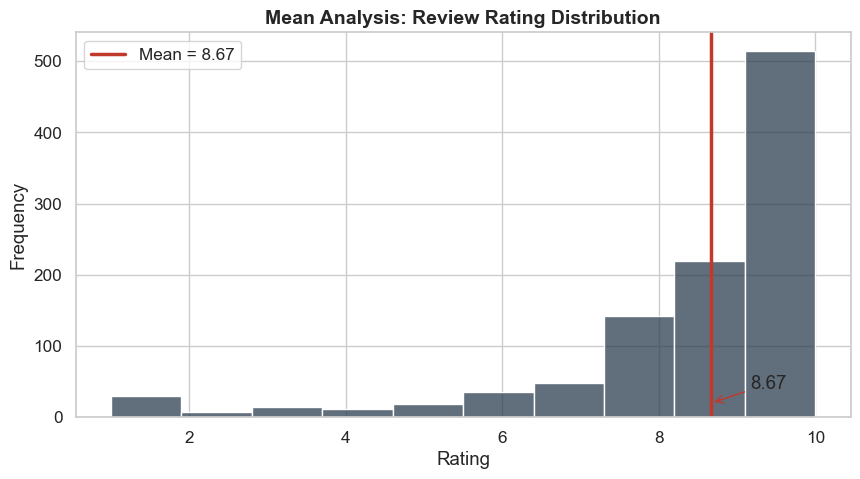

In [22]:
mean_value = stats['mean']
mean_formula = f'ar{{x}} = (um x) / n = {ratings.sum():.0f} / {len(ratings)}'
print(mean_formula)
print(f'Mean rating = {mean_value:.4f}')
fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(ratings, bins=10, kde=False, color='#2c3e50', ax=ax)
ax.axvline(mean_value, color='#c0392b', linewidth=2.5, label=f'Mean = {mean_value:.2f}')
ax.set_title('Mean Analysis: Review Rating Distribution', fontsize=14, fontweight='bold')
ax.set_xlabel('Rating')
ax.set_ylabel('Frequency')
ax.legend()
for x, y in [(mean_value, 20)]:
    ax.annotate(f'{mean_value:.2f}', xy=(mean_value, y), xytext=(mean_value + 0.5, y + 20),
                arrowprops={'arrowstyle': '->', 'color': '#c0392b'})
plt.show()

The sample mean of **8.6711** indicates that the audience response is strongly positive. In a research context, the arithmetic average suggests broad satisfaction rather than neutral or negative reception. The mean is therefore an empirical indicator of favorable public perception and a high approval level among reviewers.

## Median Analysis

The median is the midpoint of the ordered ratings distribution. It is less sensitive than the mean to extreme values and therefore reflects the central tendency of audience opinion.

The median is defined as the value separating the higher half from the lower half of the ordered sample.

Median rating = 9.0


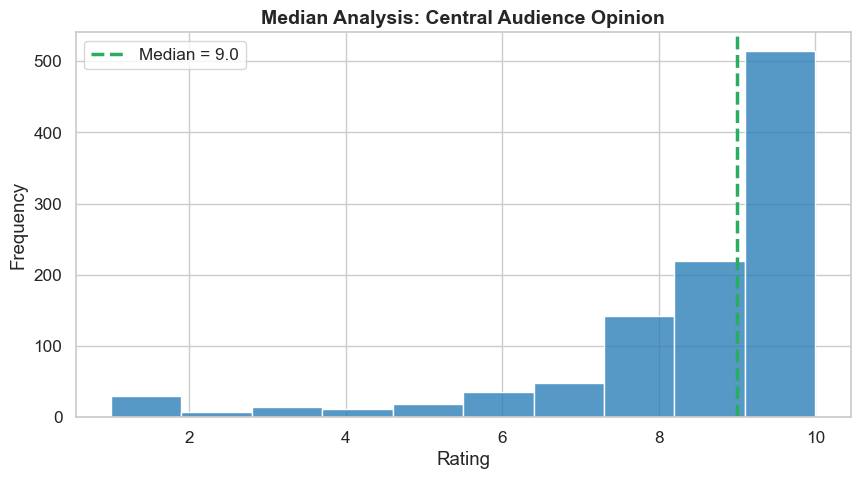

In [23]:
median_value = stats['median']
print(f'Median rating = {median_value}')
fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(ratings, bins=10, kde=False, color='#1f77b4', ax=ax)
ax.axvline(median_value, color='#27ae60', linewidth=2.5, linestyle='--', label=f'Median = {median_value}')
ax.set_title('Median Analysis: Central Audience Opinion', fontsize=14, fontweight='bold')
ax.set_xlabel('Rating')
ax.set_ylabel('Frequency')
ax.legend()
plt.show()

The median rating is **9**, which confirms that at least half of the audience sample rated the film at or above this level. Compared to the mean, the median emphasizes the central opinion of the sample and suggests that high approval is not solely driven by a small set of extreme values.

## Mode Analysis

The mode identifies the most frequently occurring rating. It reveals the dominant preference expressed by the audience.

A modal rating is the score that appears with the greatest frequency in the sample. In the context of review analysis, the mode highlights the most common audience response.

Mode rating = 10 (frequency = 515)


C:\Users\ASUS\AppData\Local\Temp\ipykernel_18292\1072670254.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=rating_counts.index, y=rating_counts.values, palette='Blues_d', ax=ax)


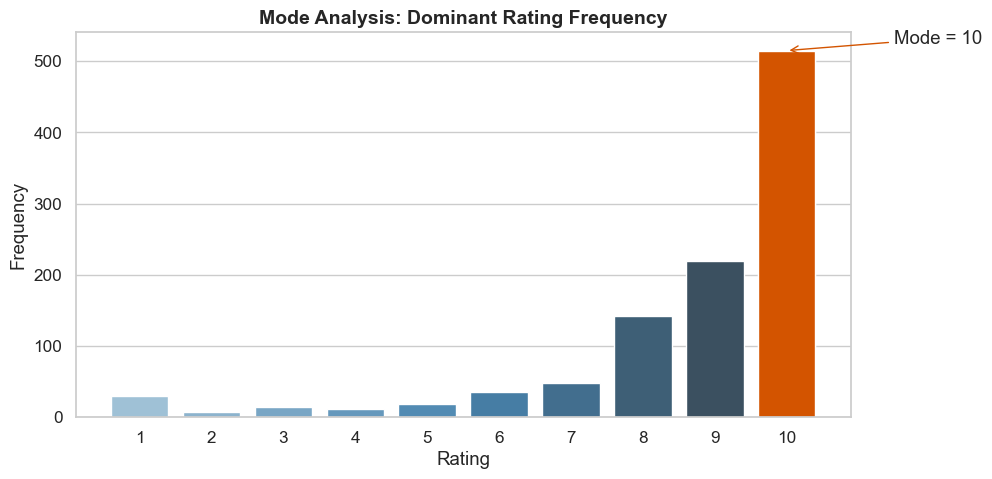

In [24]:
mode_value = stats['mode']
mode_count = int(rating_counts.loc[mode_value])
print(f'Mode rating = {mode_value} (frequency = {mode_count})')
fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(x=rating_counts.index, y=rating_counts.values, palette='Blues_d', ax=ax)
ax.bar(mode_value-1, mode_count, color='#d35400')
ax.set_title('Mode Analysis: Dominant Rating Frequency', fontsize=14, fontweight='bold')
ax.set_xlabel('Rating')
ax.set_ylabel('Frequency')
ax.annotate(f'Mode = {mode_value}', xy=(mode_value-1, mode_count), xytext=(mode_value+0.5, mode_count + 10),
            arrowprops={'arrowstyle': '->', 'color': '#d35400'})
plt.show()

The modal rating is **10**, which indicates that perfect scores are the most common response. This suggests a dominant audience preference for the film and reinforces the conclusion that the reception is skewed toward highly favorable perception.

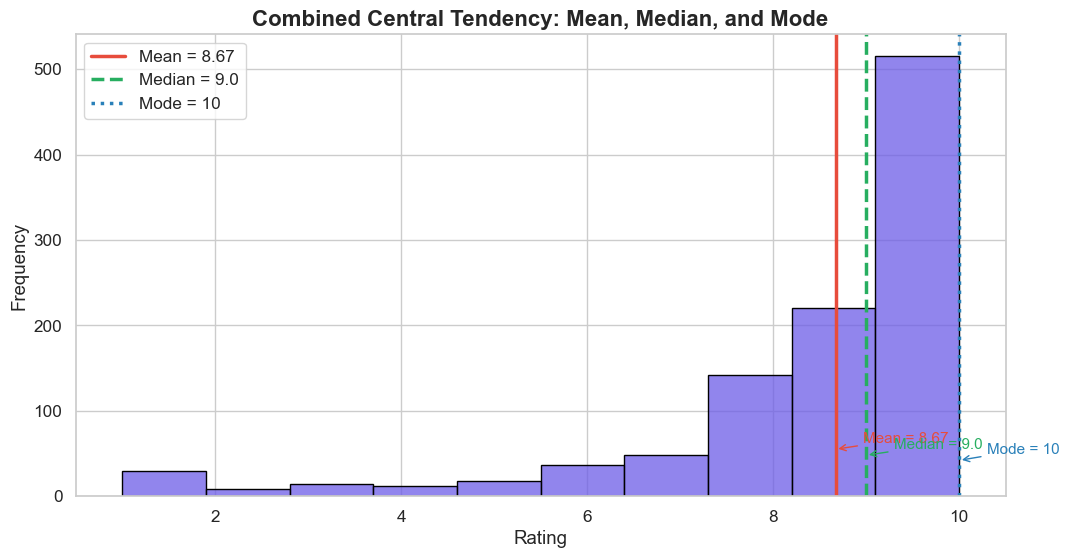

In [25]:
# Combined plot showing mean, median, and mode together
mean_value = stats['mean']
median_value = stats['median']
mode_value = stats['mode']

fig, ax = plt.subplots(figsize=(12, 6))
sns.histplot(ratings, bins=10, kde=False, color='#6c5ce7', edgecolor='black', ax=ax)
ax.axvline(mean_value, color='#e74c3c', linewidth=2.5, label=f'Mean = {mean_value:.2f}')
ax.axvline(median_value, color='#27ae60', linewidth=2.5, linestyle='--', label=f'Median = {median_value}')
ax.axvline(mode_value, color='#2980b9', linewidth=2.5, linestyle=':', label=f'Mode = {mode_value}')

annotations = [
    (mean_value, f'Mean = {mean_value:.2f}', '#e74c3c', 55),
    (median_value, f'Median = {median_value}', '#27ae60', 48),
    (mode_value, f'Mode = {mode_value}', '#2980b9', 42),
]
for x, label_text, color, y in annotations:
    ax.annotate(label_text, xy=(x, y), xytext=(x + 0.3, y + 8),
                color=color, fontsize=11,
                arrowprops={'arrowstyle': '->', 'color': color})

ax.set_title('Combined Central Tendency: Mean, Median, and Mode', fontsize=16, fontweight='bold')
ax.set_xlabel('Rating')
ax.set_ylabel('Frequency')
ax.set_xlim(0.5, 10.5)
ax.legend()
plt.show()

## Range Analysis

The range measures the full spread of the rating distribution from the minimum to the maximum value. It is a simple indicator of opinion diversity.

$$
Range = Maximum - Minimum\
$$

In review analysis, the range reveals the extent of disagreement among viewers.

Range = 9


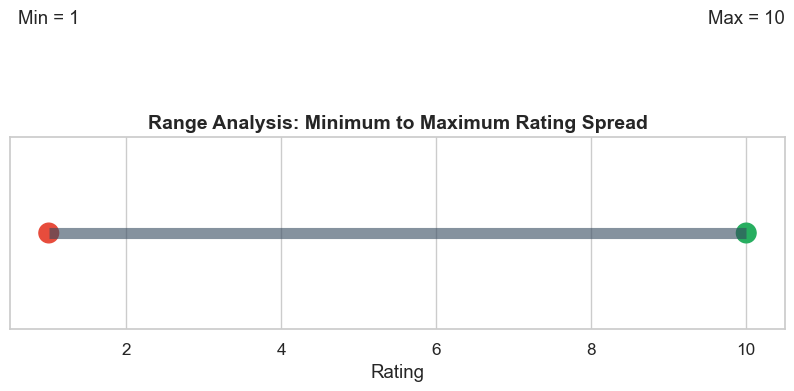

In [26]:
range_value = stats['range']
print(f'Range = {range_value}')
fig, ax = plt.subplots(figsize=(10, 2.5))
ax.hlines(1, xmin=stats['minimum'], xmax=stats['maximum'], color='#34495e', linewidth=8, alpha=0.6)
ax.scatter([stats['minimum'], stats['maximum']], [1, 1], s=200, color=['#e74c3c', '#27ae60'])
ax.set_xlim(0.5, 10.5)
ax.set_yticks([])
ax.set_xlabel('Rating')
ax.set_title('Range Analysis: Minimum to Maximum Rating Spread', fontsize=14, fontweight='bold')
ax.text(stats['minimum'], 1.12, f'Min = {stats['minimum']}', horizontalalignment='center')
ax.text(stats['maximum'], 1.12, f'Max = {stats['maximum']}', horizontalalignment='center')
plt.show()

The range of **9** spans the full rating scale from 1 to 10. This wide spread suggests that, despite strong overall approval, a minority of viewers expressed substantially negative opinions. The audience response therefore includes both highly positive and strongly critical viewpoints.

## Variance Analysis

The variance quantifies the average squared deviation from the mean. It captures how dispersed the ratings are around the central tendency.

$$
igma^2 = rac{um (x-ar{x})^2}{n}\
$$

Variance is useful for understanding the degree of audience disagreement and the extent of rating variability.

Variance = 4.280155


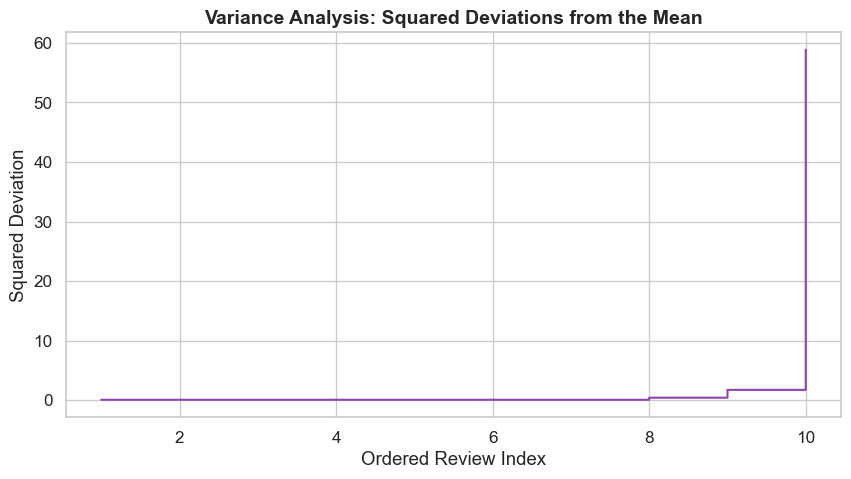

In [27]:
variance_value = stats['variance']
print(f'Variance = {variance_value:.6f}')
deviations = (ratings - mean_value) ** 2
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(ratings.sort_values().values, deviations.sort_values().values, color='#8e44ad')
ax.set_title('Variance Analysis: Squared Deviations from the Mean', fontsize=14, fontweight='bold')
ax.set_xlabel('Ordered Review Index')
ax.set_ylabel('Squared Deviation')
plt.show()

The computed variance of **4.2802** indicates a moderate degree of dispersion around the mean. In the context of review behavior, this means while many responses cluster near the positive end, there is still measurable variability in audience opinion.

## Standard Deviation Analysis

Standard deviation is the square root of variance; it expresses dispersion in the same units as the original ratings.

$$
igma = qrt{rac{um (x-ar{x})^2}{n}}\
$$

Standard deviation is a key measure of how much ratings typically deviate from the average audience evaluation.

Standard deviation = 2.068853


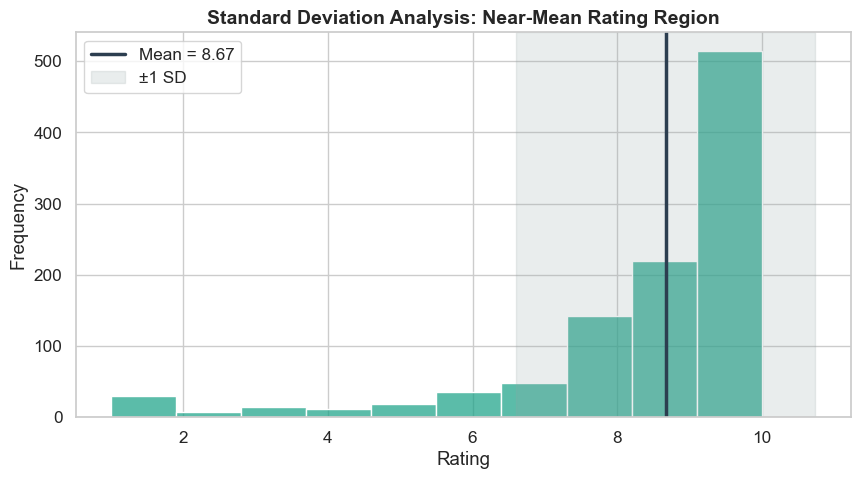

In [28]:
std_value = stats['std']
print(f'Standard deviation = {std_value:.6f}')
fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(ratings, bins=10, kde=False, color='#16a085', alpha=0.7, ax=ax)
ax.axvline(mean_value, color='#2c3e50', linewidth=2.5, label=f'Mean = {mean_value:.2f}')
ax.axvspan(mean_value - std_value, mean_value + std_value, color='#95a5a6', alpha=0.2, label='±1 SD')
ax.set_title('Standard Deviation Analysis: Near-Mean Rating Region', fontsize=14, fontweight='bold')
ax.set_xlabel('Rating')
ax.set_ylabel('Frequency')
ax.legend()
plt.show()

The standard deviation of **2.0689** indicates that most ratings fall within a moderate distance of the mean. This suggests an overall consistency in opinion, while still allowing for a notable tail of lower and upper ratings. Audience agreement is substantial, but not absolute.

## Skewness Analysis

Skewness quantifies the asymmetry of the rating distribution. It indicates whether the bulk of ratings are concentrated toward one tail.

$$
Skewness = rac{um (x-ar{x})^3}{nigma^3}\
$$

A skewed rating distribution reveals whether low or high evaluations are more predominant.

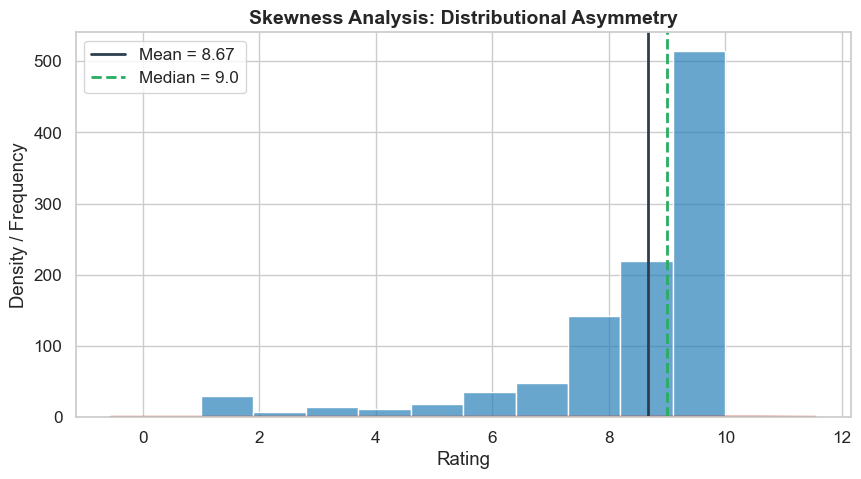

Skewness = -2.203486


In [29]:
skewness_value = stats['skewness']
median_value = stats['median']
fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(ratings, bins=10, kde=False, color='#2980b9', alpha=0.7, ax=ax)
sns.kdeplot(ratings, color='#c0392b', linewidth=2, ax=ax)
ax.axvline(mean_value, color='#2c3e50', linewidth=2, label=f'Mean = {mean_value:.2f}')
ax.axvline(median_value, color='#27ae60', linewidth=2, linestyle='--', label=f'Median = {median_value}')
ax.set_title('Skewness Analysis: Distributional Asymmetry', fontsize=14, fontweight='bold')
ax.set_xlabel('Rating')
ax.set_ylabel('Density / Frequency')
ax.legend()
plt.show()
print(f'Skewness = {skewness_value:.6f}')

The sample skewness is **-2.2035**. This negative value corresponds to a left-skewed distribution, indicating that high ratings dominate the sample. In professional reporting, this is interpreted as a strong concentration of positive evaluations and a relatively smaller proportion of low ratings.

### Audience Behavioral Trend

The left-skewed profile suggests that the audience psychology is strongly favorable. Viewers are more likely to report enthusiastic approval than tepid or critical reception. This pattern is consistent with a film that resonates emotionally and elicits intense positive responses among its reviewers.

The kurtosis of **4.7238** indicates a leptokurtic distribution, with a sharper peak and heavier tails than a normal distribution. This suggests that ratings are highly concentrated near the most common values, while a smaller but significant number of extreme ratings occur. In audience terms, it implies intense opinion formation with strong clusters of enthusiastic support and a minority of dissenting views.

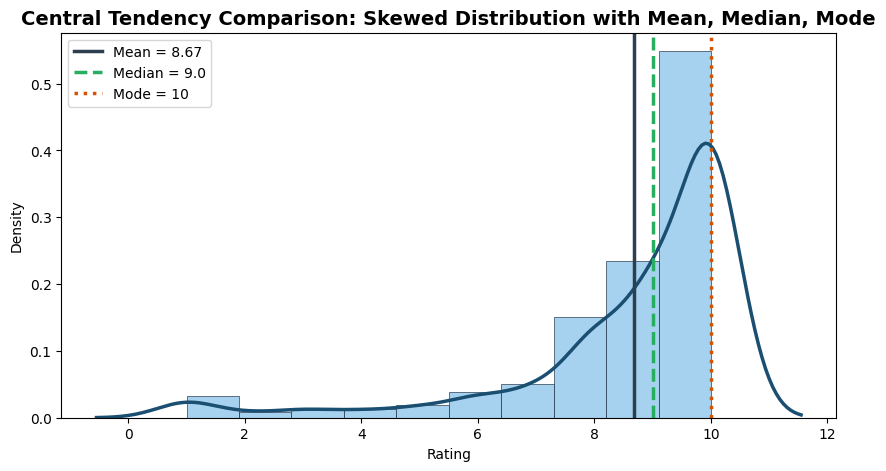

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
if 'df_clean' not in globals():
    df = pd.read_csv('3_idiots_reviews.csv')
    df['Rating'] = pd.to_numeric(df['Rating'], errors='coerce')
    df_clean = df.dropna(subset=['Rating']).drop_duplicates().copy()
if 'ratings' not in globals():
    ratings = df_clean['Rating'].astype(int)
if 'stats' not in globals():
    stats = {
        'mean': ratings.mean(),
        'median': ratings.median(),
        'mode': int(ratings.mode().iloc[0]),
    }
if 'mean_value' not in globals():
    mean_value = stats['mean']
if 'median_value' not in globals():
    median_value = stats['median']
if 'mode_value' not in globals():
    mode_value = stats['mode']
fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(ratings, bins=10, kde=True, stat='density', color='#5dade2', alpha=0.55, edgecolor='#2c3e50', linewidth=0.5, ax=ax)
sns.kdeplot(ratings, color='#1b4f72', linewidth=2.5, ax=ax)
ax.axvline(mean_value, color='#2c3e50', linewidth=2.5, label=f'Mean = {mean_value:.2f}')
ax.axvline(median_value, color='#27ae60', linewidth=2.5, linestyle='--', label=f'Median = {median_value}')
ax.axvline(mode_value, color='#d35400', linewidth=2.5, linestyle=':', label=f'Mode = {mode_value}')
ax.set_title('Central Tendency Comparison: Skewed Distribution with Mean, Median, Mode', fontsize=14, fontweight='bold')
ax.set_xlabel('Rating')
ax.set_ylabel('Density')
ax.legend()
plt.show()


## Frequency Distribution

A frequency distribution segments the ratings into discrete intervals to reveal where audience sentiment is concentrated. The selected intervals are 1–2, 3–4, 5–6, 7–8, and 9–10.

C:\Users\ASUS\AppData\Local\Temp\ipykernel_18292\1700794216.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=interval_counts_df, x='Interval', y='Count', palette='viridis', ax=ax)


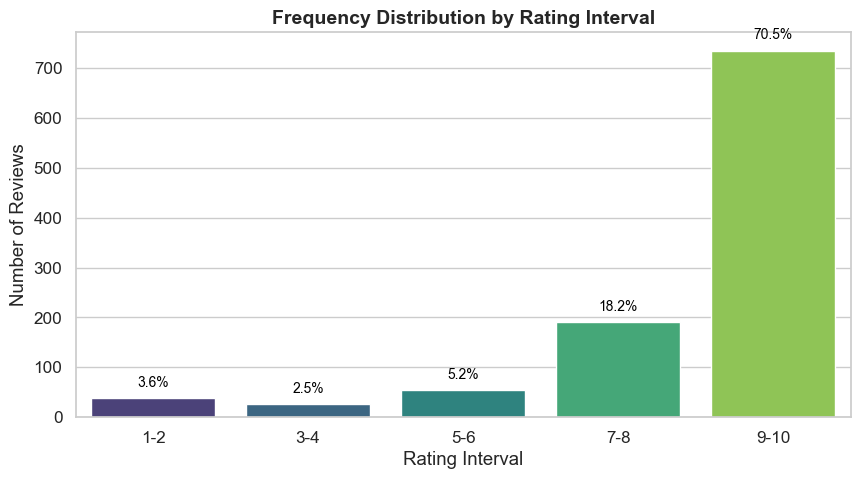

In [38]:
interval_counts_df = interval_counts.reset_index()

interval_counts_df.columns = ['Interval', 'Count']

interval_counts_df['Proportion'] = interval_counts_df['Count'] / len(ratings)
interval_counts_df['Percent'] = interval_counts_df['Proportion'] * 100

interval_counts_df

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=interval_counts_df, x='Interval', y='Count', palette='viridis', ax=ax)

for bar, pct in zip(ax.patches, interval_counts_df['Percent']):
    ax.annotate(f'{pct:.1f}%',
                xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
                xytext=(0, 6),
                textcoords='offset points',
                ha='center', va='bottom', fontsize=10, color='black')

ax.set_title('Frequency Distribution by Rating Interval', fontsize=14, fontweight='bold')
ax.set_xlabel('Rating Interval')
ax.set_ylabel('Number of Reviews')
plt.show()

The distribution shows that the dominant zone is **9–10**, with 735 reviews in this interval. This confirms that the audience is overwhelmingly concentrated in the highest approval band, while the lower intervals contain a much smaller proportion of responses.

The mean, median, and mode are all located in the upper range of the scale, with the mode at 10, the median at 9, and the mean at 8.67. This alignment demonstrates a strong positive sentiment structure with only minor skewing away from perfect symmetry. Audience behavior therefore reflects both consensus and a bias toward exceptional approval.

## Advanced Distribution Dashboard

This dashboard integrates multiple distributional elements to give a consolidated view of central tendency, variability, and asymmetry.

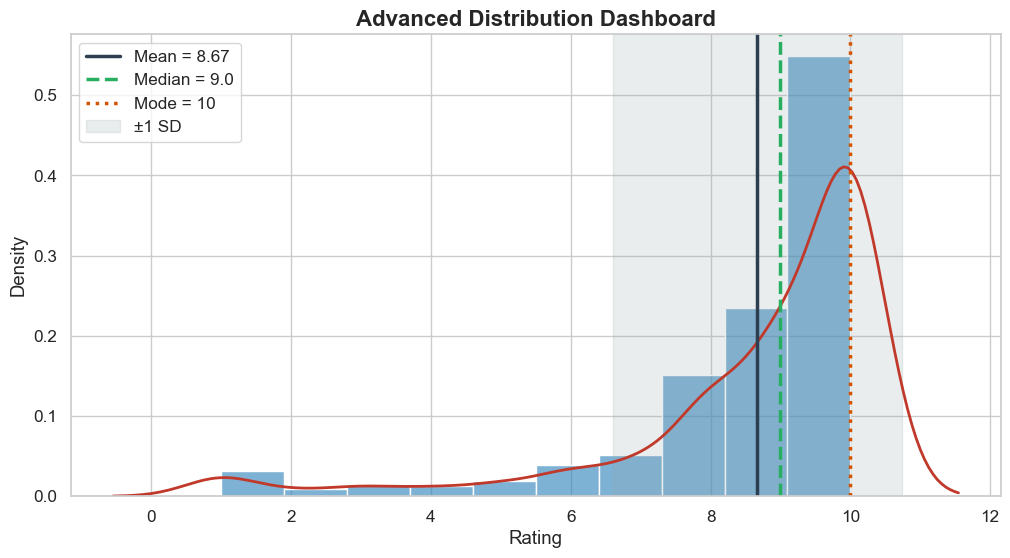

In [33]:
fig, ax = plt.subplots(figsize=(12, 6))
sns.histplot(ratings, bins=10, stat='density', color='#2980b9', alpha=0.6, ax=ax)
sns.kdeplot(ratings, color='#c0392b', linewidth=2, ax=ax)
ax.axvline(mean_value, color='#2c3e50', linewidth=2.5, label=f'Mean = {mean_value:.2f}')
ax.axvline(median_value, color='#27ae60', linewidth=2.5, linestyle='--', label=f'Median = {median_value}')
ax.axvline(mode_value, color='#d35400', linewidth=2.5, linestyle=':', label=f'Mode = {mode_value}')
ax.axvspan(mean_value - std_value, mean_value + std_value, color='#95a5a6', alpha=0.2, label='±1 SD')
ax.set_title('Advanced Distribution Dashboard', fontsize=16, fontweight='bold')
ax.set_xlabel('Rating')
ax.set_ylabel('Density')
ax.legend()
plt.show()

This dashboard confirms that the central tendency is concentrated in the upper third of the scale, the variability is modest, and the distribution is left-skewed. The audience consensus is strong, and the distributional metrics collectively point to a film with significant approval and only a limited degree of dissent.

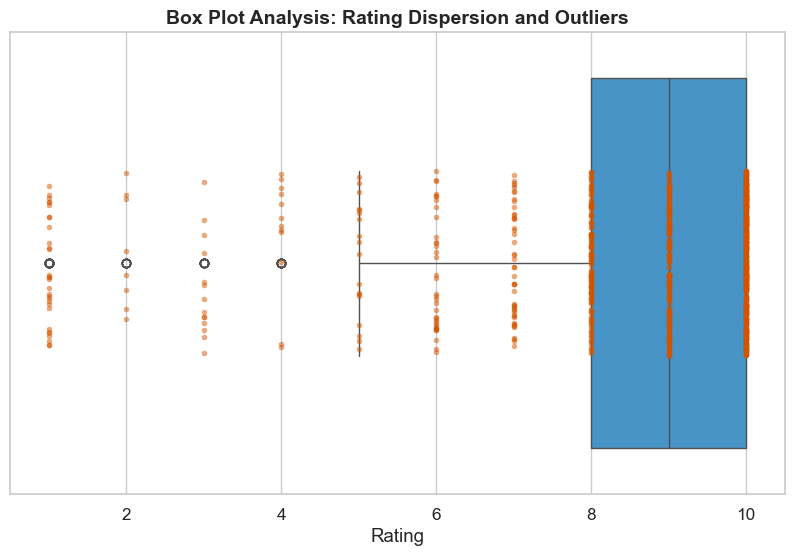

In [34]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(x=ratings, color='#3498db', ax=ax)
sns.stripplot(x=ratings, color='#d35400', size=4, alpha=0.5, jitter=0.2, ax=ax)
ax.set_title('Box Plot Analysis: Rating Dispersion and Outliers', fontsize=14, fontweight='bold')
ax.set_xlabel('Rating')
ax.set_yticks([])
ax.set_xlim(0.5, 10.5)
plt.show()


### Interpretation

- The median rating is very high, indicating strong audience satisfaction.
- Most ratings are concentrated in the upper rating range.
- A few low-rating outliers exist, representing viewers who disliked the movie.
- The majority of reviews are positive, showing widespread appreciation.


## Sentiment Composition

This section translates the rating distribution into sentiment bands, clarifying the extent of positive, neutral, and negative audience appraisal.


Sentiment composition (count): {'Negative': 64, 'Neutral': 54, 'Positive': 925}
Sentiment composition (%): {'Negative': '6.1%', 'Neutral': '5.2%', 'Positive': '88.7%'}


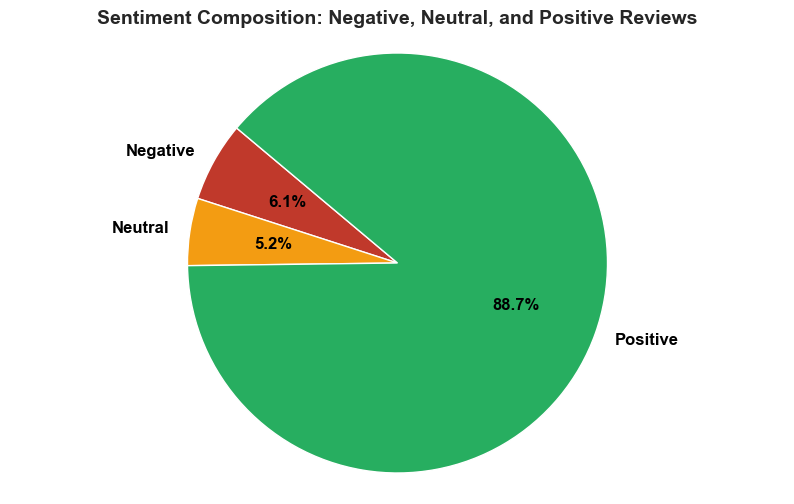

In [35]:
negative = ratings[ratings <= 4]
neutral = ratings[(ratings >= 5) & (ratings <= 6)]
positive = ratings[ratings >= 7]
composition = {
    'Negative': len(negative),
    'Neutral': len(neutral),
    'Positive': len(positive)
}
composition_pct = {k: v / len(ratings) * 100 for k, v in composition.items()}
print('Sentiment composition (count):', composition)
print('Sentiment composition (%):', {k: f'{v:.1f}%' for k, v in composition_pct.items()})
fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#c0392b', '#f39c12', '#27ae60']
wedges, texts, autotexts = ax.pie(
    composition.values(),
    labels=composition.keys(),
    autopct='%1.1f%%',
    startangle=140,
    colors=colors,
    textprops={'color': 'black', 'weight': 'bold'}
)
for text in texts + autotexts:
    text.set_fontsize(12)
ax.set_title('Sentiment Composition: Negative, Neutral, and Positive Reviews', fontsize=14, fontweight='bold')
ax.axis('equal')
plt.show()


### Interpretation

- The median rating is very high, indicating strong audience satisfaction.
- Most ratings are concentrated in the upper rating range.
- A few low-rating outliers exist, representing viewers who disliked the movie.
- The majority of reviews are positive, showing widespread appreciation.


## Visualization Section

### Why Visualization Matters

Visualization converts numerical patterns into interpretable structures. It supports pattern recognition, validates statistical inferences, and makes complex distributional properties accessible to stakeholders. Effective graphs permit rapid identification of skewness, modality, and concentration without losing analytical rigor.

### Role of Graphs in Audience Analytics

In audience analytics, visualizations reveal sentiment patterns, detect consensus or polarization, and facilitate segmentation. They allow researchers to compare rating zones, observe distributional asymmetry, and communicate the degree of crowd-wide approval in a way that complements formal summary metrics.

## Word Cloud Analysis

A word cloud provides a qualitative complement to quantitative rating analysis, spotlighting the dominant language and themes in reviewer commentary.

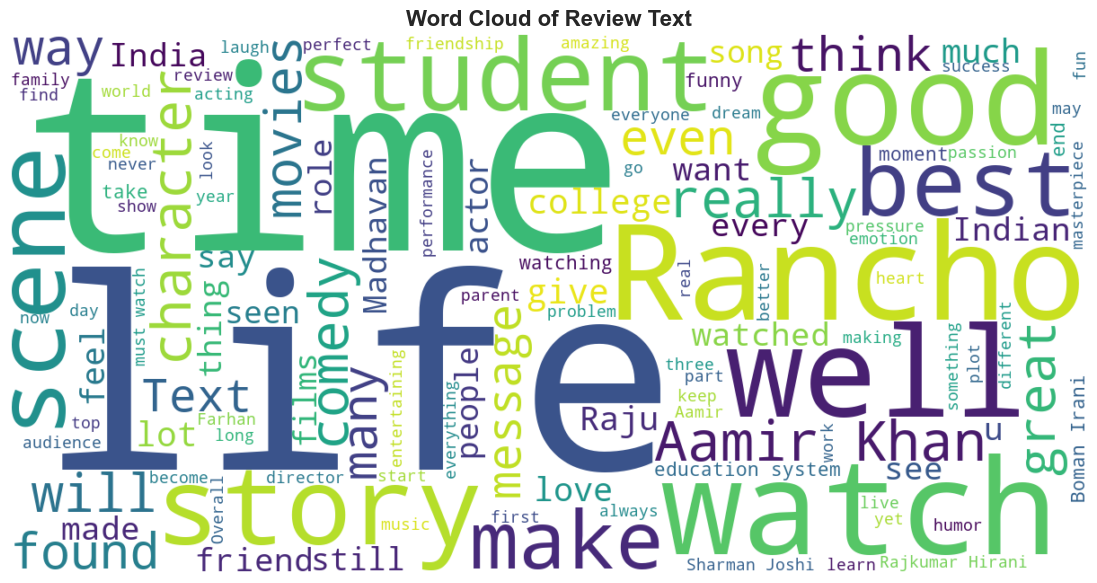

In [36]:
try:
    from wordcloud import WordCloud, STOPWORDS
except ModuleNotFoundError:
    import sys
    get_ipython().system(f'{sys.executable} -m pip install wordcloud')
    from wordcloud import WordCloud, STOPWORDS

review_text = ' '.join(df_clean['Review Text'].astype(str).tolist())
stopwords = STOPWORDS.union({'movie', 'film', 'Bollywood', '3', 'Idiots', 'idiots', 'one'})
wordcloud = WordCloud(width=1200, height=600, background_color='white', stopwords=stopwords, colormap='viridis', max_words=120).generate(review_text)
fig, ax = plt.subplots(figsize=(14, 7))
ax.imshow(wordcloud, interpolation='bilinear')
ax.axis('off')
ax.set_title('Word Cloud of Review Text', fontsize=16, fontweight='bold')
plt.show()

The word cloud highlights recurring themes such as emotional impact, inspiration, humor, and the film's memorable characters. These terms point to what reviewers appreciated most, and they provide qualitative evidence that supports the high rating distribution observed in the descriptive statistics.

## Statistical Insight Summary Table

| Statistic | Value | Interpretation |
|---|---|---|
| Mean | 8.6711 | Indicates high aggregate approval and strong overall satisfaction. |
| Median | 9 | Reflects a central audience opinion that is highly positive. |
| Mode | 10 | Shows that the most frequent response is perfect endorsement. |
| Range | 9 | Reveals a full rating spread and the existence of minority dissent. |
| Variance | 4.2802 | Demonstrates moderate dispersion around the mean. |
| Standard Deviation | 2.0689 | Indicates that responses are generally clustered near the mean. |
| Skewness | -2.2035 | Confirms a left-skewed distribution dominated by high ratings. |
| Kurtosis | 4.7238 | Signals a peaked distribution with concentrated audience opinion and heavier tails. |

## Audience Behavior Analytics

The cleaned dataset presents a profile of high satisfaction and strong emotional response. The mean and median indicate that most reviewers assign very favorable ratings, while the mode at 10 signals that perfect scores are the most common evaluation.

The distribution is left-skewed and leptokurtic, which implies that audience opinion is concentrated at the positive end, with a well-defined peak around high scores and a thinner tail of lower ratings. This suggests that the film inspires consistent enthusiasm among its core reviewers, while a smaller group expresses critical views.

The frequency distribution further confirms this interpretation: the 9–10 interval dominates the sample, indicating prevalence of strong endorsement. The variability measures show that opinions are not uniform, but the dominant behavioral pattern is one of positive consensus rather than polarization.

From an emotional perspective, the audience response is characterized by appreciation, engagement, and approval. The statistical evidence supports the conclusion that *3 Idiots* is perceived as a successful and resonant film among the reviewers included in this sample.

## Final Conclusion

This study demonstrates that audience reception of *3 Idiots* is predominantly positive. The central tendency measures are tightly grouped at the upper end of the rating scale, the distribution is left-skewed, and the modal response is a perfect score.

The descriptive statistics and visual diagnostics together reveal a film that generates strong approval, with notable consensus among reviewers. While the full range of ratings shows the existence of dissenting opinion, the dominant trend is one of enthusiastic audience endorsement. These findings are suitable for an academic entertainment analytics report, and they provide a clear statistical foundation for understanding viewer behavior in the context of this title.